In [ ]:
! pip install langgraph langchain-openai typing_extensions ipython

In [45]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [46]:
import os
from langchain_openai import ChatOpenAI
import getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [47]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

Defining a graph state

In [48]:
class State(TypedDict):
    topic: str
    audience: str
    requirements: str
    outline: str
    draft: str
    final_answer: str


Node 1: Extract Requirements

In [49]:
def extract_requirements(state: State):
    prompt = f"""
You are a teaching assistant.

Topic: {state['topic']}
Audience: {state['audience']}

Extract the key requirements for explaining this topic clearly.
Return 4 to 6 bullet points only.
"""
    msg = llm.invoke(prompt)
    return {"requirements": msg.content}


Node 2: Outline Generator

In [50]:
def create_outline(state: State):
    prompt = f"""
Create a simple teaching outline using the requirements below.

Topic: {state['topic']}
Audience: {state['audience']}

Requirements:
{state['requirements']}

Return a clear numbered outline.
"""
    msg = llm.invoke(prompt)
    return {"outline": msg.content}


Node 3: Content Writer

In [51]:
def write_draft(state: State):
    prompt = f"""
Write a beginner-friendly explanation using this outline.

Topic: {state['topic']}
Audience: {state['audience']}

Outline:
{state['outline']}

Rules:
- Use simple language.
- Use one small example.
- Keep it concise.
"""
    msg = llm.invoke(prompt)
    return {"draft": msg.content}


Node 4: Reviewer

In [52]:
def review_and_finalize(state: State):
    prompt = f"""
Improve the explanation below.

Make it clearer, more beginner-friendly, and better structured.
Do not add unnecessary length.

Draft:
{state['draft']}
"""
    msg = llm.invoke(prompt)
    return {"final_answer": msg.content}


Build the LangGraph Workflow

This workflow is linear.

That makes it easier to understand prompt chaining clearly.


In [53]:
workflow = StateGraph(State)

workflow.add_node("extract_requirements", extract_requirements)
workflow.add_node("create_outline", create_outline)
workflow.add_node("write_draft", write_draft)
workflow.add_node("review_and_finalize", review_and_finalize)

workflow.add_edge(START, "extract_requirements")
workflow.add_edge("extract_requirements", "create_outline")
workflow.add_edge("create_outline", "write_draft")
workflow.add_edge("write_draft", "review_and_finalize")
workflow.add_edge("review_and_finalize", END)

chain = workflow.compile()


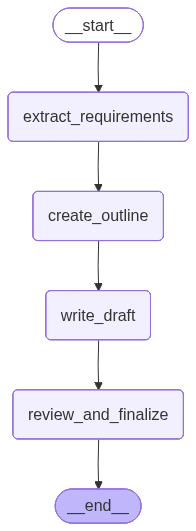

In [54]:
display(Image(chain.get_graph().draw_mermaid_png()))


Run the Prompt Chain

The input only contains the topic and audience.

Everything else is generated step by step by the chain.


In [55]:
result = chain.invoke({
    "topic": "What is LangGraph?",
    "audience": "beginner Python students"
})

print("REQUIREMENTS")
print("=" * 80)
print(result["requirements"])

print("\nOUTLINE")
print("=" * 80)
print(result["outline"])

print("\nDRAFT")
print("=" * 80)
print(result["draft"])

print("\nFINAL ANSWER")
print("=" * 80)
print(result["final_answer"])


REQUIREMENTS
- **Definition**: Start with a clear and simple definition of LangGraph, explaining its purpose and functionality in the context of programming or data analysis.

- **Core Concepts**: Introduce the fundamental concepts behind LangGraph, such as graphs, nodes, and edges, and how they relate to data representation.

- **Use Cases**: Provide examples of practical applications where LangGraph can be utilized, such as in natural language processing or data visualization.

- **Installation and Setup**: Briefly outline the steps needed to install LangGraph and set up the environment for beginners to start using it.

- **Basic Syntax and Functions**: Highlight some basic syntax and key functions or methods in LangGraph that beginners should know to get started.

- **Resources for Learning**: Suggest additional resources, such as documentation, tutorials, or community forums, where students can find more information and support.

OUTLINE
# Teaching Outline: What is LangGraph?

## 1